<a href="https://colab.research.google.com/github/LayanJunaid/heart-disease-prediction/blob/data_processing/03_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction
# Phase 3 — Data Preprocessing
### UCI Cleveland Heart Disease Dataset

---

**Continues from:** `01_data_loading_eda.ipynb` (done by teammates)

**What teammates already did:**
- Loaded `processed.cleveland.data` with correct column names
- Replaced `?` with `NaN` automatically via `na_values='?'`
- Converted `condition` column to binary (0 = No Disease, 1 = Disease)
- Explored the dataset: shape, types, missing values, target distribution, feature descriptions

**What this notebook does (our responsibility):**
1. Re-load the data (same way teammates did — to stay consistent)
2. Define column types (numerical / categorical / binary)
3. Handle missing values → KNN Imputer
4. Handle outliers → IQR Capping
5. Encode categorical features → One-Hot Encoding
6. Visualize distributions before & after preprocessing
7. Separate features (X) from target (y)
8. Train / Test split (stratified)
9. Balance classes → SMOTE (on train only)
10. Scale features → StandardScaler (fit on train only)
11. Final validation checks
12. Save all outputs for the Feature Selection notebook
13. Full summary report

---
## 📦 Cell 1 — Install & Import Libraries

In [4]:
# ============================================================
# CELL 1 — Install & Import All Required Libraries
# ============================================================

# imbalanced-learn is not pre-installed in Colab → install it first
# 'quiet' flag suppresses the long installation output
#!pip install imbalanced-learn --quiet

# --- Core data manipulation ---
import pandas as pd          # DataFrames — our main data structure
import numpy as np           # Numerical operations (arrays, math)

# --- Visualization ---
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Higher-level statistical plots

# --- Preprocessing tools (from scikit-learn) ---
from sklearn.impute import KNNImputer              # Smart missing value handler
from sklearn.preprocessing import StandardScaler   # Feature scaling (z-score)
from sklearn.model_selection import train_test_split  # Split data into train/test

# --- Class balancing ---
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling

# --- Utilities ---
import os       # File & folder operations
import joblib   # Save/load Python objects (models, arrays, scalers)
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings

# --- Global plot settings (matching teammates' style) ---
sns.set_theme(style='whitegrid', palette='muted')  # Same theme as EDA notebook
plt.rcParams['figure.figsize'] = (10, 6)           # Default figure size
plt.rcParams['font.size'] = 11

print('=' * 55)
print('  ✅ All libraries imported successfully!')
print('=' * 55)

  ✅ All libraries imported successfully!


---
## 📂 Cell 2 — Re-load the Dataset

> **Why re-load?** Each notebook runs independently in Colab.
> We must reload the data exactly the same way teammates did so everything stays consistent.

In [5]:
# ============================================================
# CELL 2 — Load the Dataset (same method as EDA notebook)
# ============================================================

# Upload the raw file from your local machine
# A file-picker dialog will appear — select 'processed.cleveland.data'
from google.colab import files
uploaded = files.upload()
# --- Column names (the raw file has NO header row) ---
# These are the 14 standard UCI Cleveland feature names
col_names = [
    'age',      # Age of the patient in years
    'sex',      # Sex (1 = male, 0 = female)
    'cp',       # Chest pain type (0-3)
    'trestbps', # Resting blood pressure (mmHg)
    'chol',     # Serum cholesterol (mg/dl)
    'fbs',      # Fasting blood sugar > 120 mg/dl (1=True, 0=False)
    'restecg',  # Resting ECG result (0-2)
    'thalach',  # Maximum heart rate achieved
    'exang',    # Exercise-induced angina (1=Yes, 0=No)
    'oldpeak',  # ST depression (exercise vs rest)
    'slope',    # Slope of peak exercise ST segment (0-2)
    'ca',       # Number of major vessels (0-3) — had '?' in raw file
    'thal',     # Thalassemia type (0-3) — had '?' in raw file
    'condition' # TARGET: 0=No disease, originally 0-4, converted to binary
]

# Read the CSV — na_values='?' tells pandas to treat '?' as NaN immediately
# This is exactly what teammates did so our NaN handling will be consistent
# df = pd.read_csv(
#     'processed.cleveland.data',
#     names=col_names,
#     na_values='?'     # '?' → NaN automatically on load
#

df = pd.read_csv('processed.cleveland.data',
                 names=col_names,
                 na_values='?')

# --- Convert target to binary (same as teammates did) ---
# Original values: 0 = no disease, 1/2/3/4 = disease present
# We convert to: 0 = no disease, 1 = disease (binary classification)
df['condition'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)

# --- Quick confirmation ---
print('Dataset loaded successfully!')
print(f'Shape  : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Target : condition  →  {df["condition"].value_counts().to_dict()}')
print(f'Missing: {df.isnull().sum().sum()} total NaN values')
display(df.head())

Saving processed.cleveland.data to processed.cleveland (1).data
Dataset loaded successfully!
Shape  : 303 rows × 14 columns
Target : condition  →  {0: 164, 1: 139}
Missing: 6 total NaN values


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## 🏷️ Cell 3 — Define Column Types

> **Why define types manually?**  
> Pandas sees everything as numbers here, but some columns represent *categories* (e.g., `cp=3` does NOT mean "3 times more" than `cp=0`).  
> Each type needs different treatment: numerical → scaling, categorical → encoding, binary → leave as-is.

In [6]:
# ============================================================
# CELL 3 — Define Column Types
# ============================================================

# TARGET column — what we want to predict
TARGET_COL = 'condition'

# CONTINUOUS (truly numerical) → need Outlier Capping + Scaling later
# These are real measurements on a continuous scale
continuous_cols = [
    'age',       # 29–77 years
    'trestbps',  # 94–200 mmHg
    'chol',      # 126–564 mg/dl
    'thalach',   # 71–202 bpm
    'oldpeak'    # 0–6.2 (ST depression)
]

# CATEGORICAL (discrete, unordered) → need One-Hot Encoding later
# Numbers here are labels — NOT ordered magnitudes
categorical_cols = [
    'cp',       # 4 types of chest pain (0,1,2,3)
    'restecg',  # 3 ECG results (0,1,2)
    'slope',    # 3 slope types (0,1,2)
    'thal',     # 4 thalassemia types (0,1,2,3) — also had missing values
    'ca'        # vessels count (0-3) — treated as categorical + had missing values
]

# BINARY (already 0/1) → no encoding needed, leave as-is
binary_cols = [
    'sex',    # 0 or 1
    'fbs',    # 0 or 1
    'exang'   # 0 or 1
]

# --- Sanity check: make sure all columns are accounted for ---
all_defined = set(continuous_cols + categorical_cols + binary_cols + [TARGET_COL])
all_actual  = set(df.columns)
unaccounted = all_actual - all_defined

print('Column Type Definitions:')
print(f'  Continuous  ({len(continuous_cols)}) : {continuous_cols}')
print(f'  Categorical ({len(categorical_cols)}) : {categorical_cols}')
print(f'  Binary      ({len(binary_cols)}) : {binary_cols}')
print(f'  Target           : "{TARGET_COL}"')
print()
if unaccounted:
    print(f'  ⚠️  Unaccounted columns: {unaccounted}  → fix the lists above')
else:
    print('  ✅ All 14 columns accounted for!')

Column Type Definitions:
  Continuous  (5) : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Categorical (5) : ['cp', 'restecg', 'slope', 'thal', 'ca']
  Binary      (3) : ['sex', 'fbs', 'exang']
  Target           : "condition"

  ✅ All 14 columns accounted for!


---
## 🔧 Cell 4 — Handle Missing Values (KNN Imputer)

> **Why KNN Imputer?**  
> Simple strategies (mean/median) ignore relationships between features.  
> KNN Imputer finds the 5 most similar rows and fills the gap using their values — much smarter for medical data.  
>
> **What's missing here?** Only `ca` and `thal` — 6 rows total (~2% of data).

Missing Values BEFORE Imputation:
----------------------------------------
  ca        : 4 missing (1.3%)
  thal      : 2 missing (0.7%)
  TOTAL    : 6 missing values

Applying KNN Imputer (k=5)...
Missing values AFTER imputation: 0


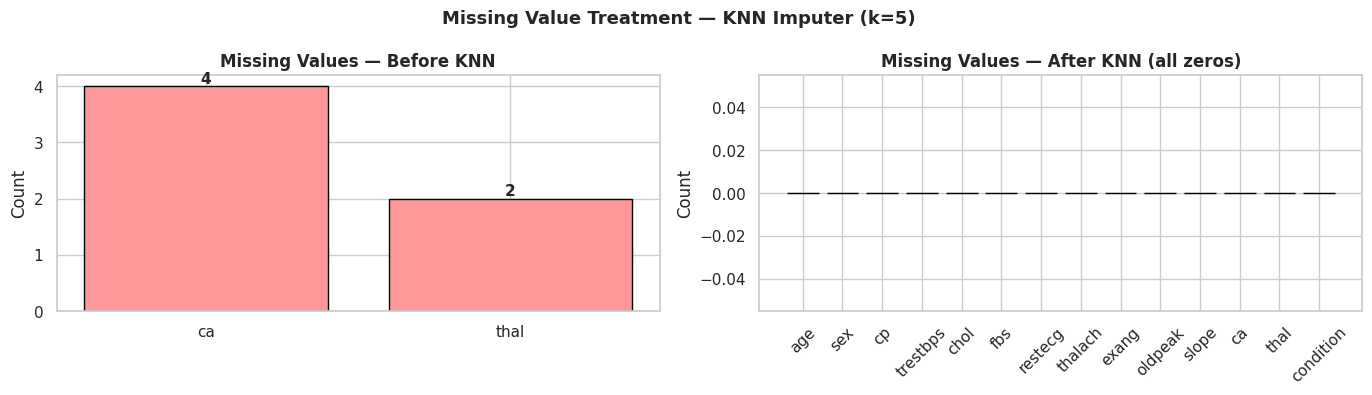

  ✅ Missing values handled!


In [7]:
# ============================================================
# CELL 4 — Handle Missing Values with KNN Imputer
# ============================================================

# Always work on a copy — never modify the raw loaded data
# This lets us re-run from Cell 2 if something goes wrong
df_clean = df.copy()

# --- Step 1: Check missing values before imputation ---
missing_before = df_clean.isnull().sum()
total_before   = missing_before.sum()

print('Missing Values BEFORE Imputation:')
print('-' * 40)
# Only print columns that actually have missing values
for col, count in missing_before[missing_before > 0].items():
    pct = count / len(df_clean) * 100
    print(f'  {col:<10}: {count} missing ({pct:.1f}%)')
print(f'  TOTAL    : {total_before} missing values')

# --- Step 2: Apply KNN Imputer ---
# n_neighbors=5 → looks at 5 most similar patients and fills with their average
# We apply it to ALL columns at once (it handles the whole DataFrame)
print('\nApplying KNN Imputer (k=5)...')
knn_imputer = KNNImputer(n_neighbors=5)

# fit_transform learns from AND transforms the data
# Note: at this stage we impute the full df_clean (before split)
# This is acceptable here because we're imputing, not scaling
df_clean[df_clean.columns] = knn_imputer.fit_transform(df_clean)

# KNN outputs floats — round columns that must be integers
# ca and thal should be whole numbers (0,1,2,3)
for col in ['ca', 'thal']:
    df_clean[col] = df_clean[col].round().astype(int)

# Also ensure target stays integer 0/1
df_clean[TARGET_COL] = df_clean[TARGET_COL].round().astype(int)

# --- Step 3: Confirm no more missing values ---
total_after = df_clean.isnull().sum().sum()
print(f'Missing values AFTER imputation: {total_after}')

# --- Step 4: Visualize before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before — show only columns with missing
cols_with_missing = missing_before[missing_before > 0]
if len(cols_with_missing) > 0:
    axes[0].bar(cols_with_missing.index, cols_with_missing.values,
                color='#ff9999', edgecolor='black')
    for i, v in enumerate(cols_with_missing.values):
        axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center',
                 transform=axes[0].transAxes, fontsize=13)
axes[0].set_title('Missing Values — Before KNN', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# After
after_missing = df_clean.isnull().sum()
axes[1].bar(df_clean.columns, after_missing.values, color='#66b3ff', edgecolor='black')
axes[1].set_title('Missing Values — After KNN (all zeros)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Missing Value Treatment — KNN Imputer (k=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prep_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('  ✅ Missing values handled!')

---
## 📊 Cell 5 — Outlier Detection & Treatment (IQR Capping)

> **Why IQR(Interquartile Range ) Capping instead of deletion?**  
> We only have 303 rows. Deleting outliers loses real patient data.  
> Capping (Winsorization) clips extreme values to the boundary — keeps all rows, just limits the extremes.  
>
> **IQR Rule:** Any value below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` is considered an outlier.

Outlier Analysis — IQR Method (continuous features only):
  age        | Outliers:  0 | Bounds: [28.5, 80.5]
  trestbps   | Outliers:  9 | Bounds: [90.0, 170.0]
  chol       | Outliers:  5 | Bounds: [115.0, 371.0]
  thalach    | Outliers:  1 | Bounds: [84.8, 214.8]
  oldpeak    | Outliers:  5 | Bounds: [-2.4, 4.0]
  Total values capped: 20


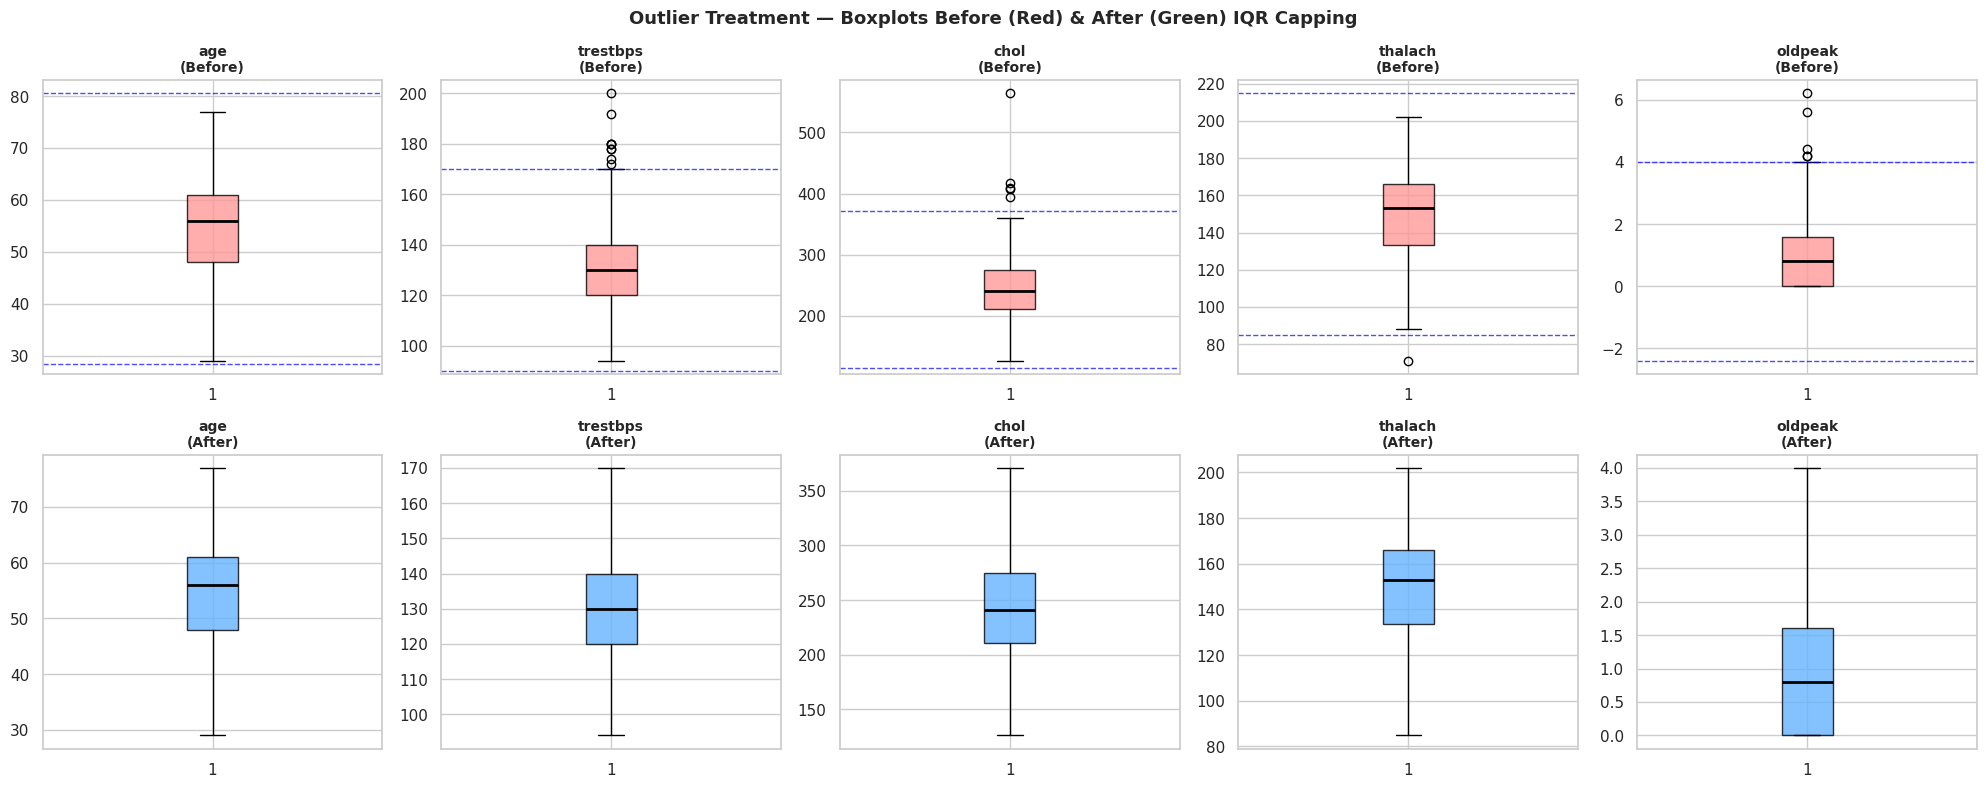

  ✅ Outliers handled with IQR Capping!


In [8]:
# ============================================================
# CELL 5 — Outlier Detection & Treatment (IQR Capping)
# ============================================================

# We only cap CONTINUOUS columns — categorical/binary outliers don't make sense
print('Outlier Analysis — IQR Method (continuous features only):')
print('=' * 60)

# Dictionary to store IQR bounds — we'll need these for the report
iqr_bounds = {}
total_capped = 0

for col in continuous_cols:
    Q1    = df_clean[col].quantile(0.25)   # 25th percentile
    Q3    = df_clean[col].quantile(0.75)   # 75th percentile
    IQR   = Q3 - Q1                         # Interquartile range
    lower = Q1 - 1.5 * IQR                  # Lower fence
    upper = Q3 + 1.5 * IQR                  # Upper fence

    # Count how many values fall outside the fences
    n_outliers = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    total_capped += n_outliers
    iqr_bounds[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'lower': lower, 'upper': upper}

    # clip() replaces values below lower with lower, above upper with upper
    # It does NOT delete rows — just limits (caps) the extreme values
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f'  {col:<10} | Outliers: {n_outliers:>2} | '
          f'Bounds: [{lower:.1f}, {upper:.1f}]')

print('=' * 60)
print(f'  Total values capped: {total_capped}')

# --- Visualization: Boxplots before vs after ---
# We re-load the original to get the 'before' state for comparison
df_original = pd.read_csv('processed.cleveland.data', names=col_names, na_values='?')

fig, axes = plt.subplots(2, len(continuous_cols), figsize=(20, 8))
fig.suptitle('Outlier Treatment — Boxplots Before (Red) & After (Green) IQR Capping',
             fontsize=13, fontweight='bold')

for i, col in enumerate(continuous_cols):
    # --- ROW 0: Before capping (original data) ---
    bp0 = axes[0][i].boxplot(
        df_original[col].dropna(),
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp0['boxes'][0].set_facecolor('#ff9999')  # Red = before
    bp0['boxes'][0].set_alpha(0.8)
    axes[0][i].set_title(f'{col}\n(Before)', fontsize=10, fontweight='bold')

    # Draw the IQR fence lines so we can see what was capped
    axes[0][i].axhline(iqr_bounds[col]['upper'], color='blue',
                       linestyle='--', linewidth=1, alpha=0.7, label='upper fence')
    axes[0][i].axhline(iqr_bounds[col]['lower'], color='blue',
                       linestyle='--', linewidth=1, alpha=0.7, label='lower fence')

    # --- ROW 1: After capping (cleaned data) ---
    bp1 = axes[1][i].boxplot(
        df_clean[col],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp1['boxes'][0].set_facecolor('#66b3ff')  # Blue = after
    bp1['boxes'][0].set_alpha(0.8)
    axes[1][i].set_title(f'{col}\n(After)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('prep_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print('  ✅ Outliers handled with IQR Capping!')

---
## 📊 Cell 6 — Distribution Plots After Cleaning

> **Why visualize again?**  
> After imputation and capping, we need to confirm the distributions look medically reasonable.  
> We also compare each feature's distribution between sick (1) and healthy (0) patients — this is key insight for the project.

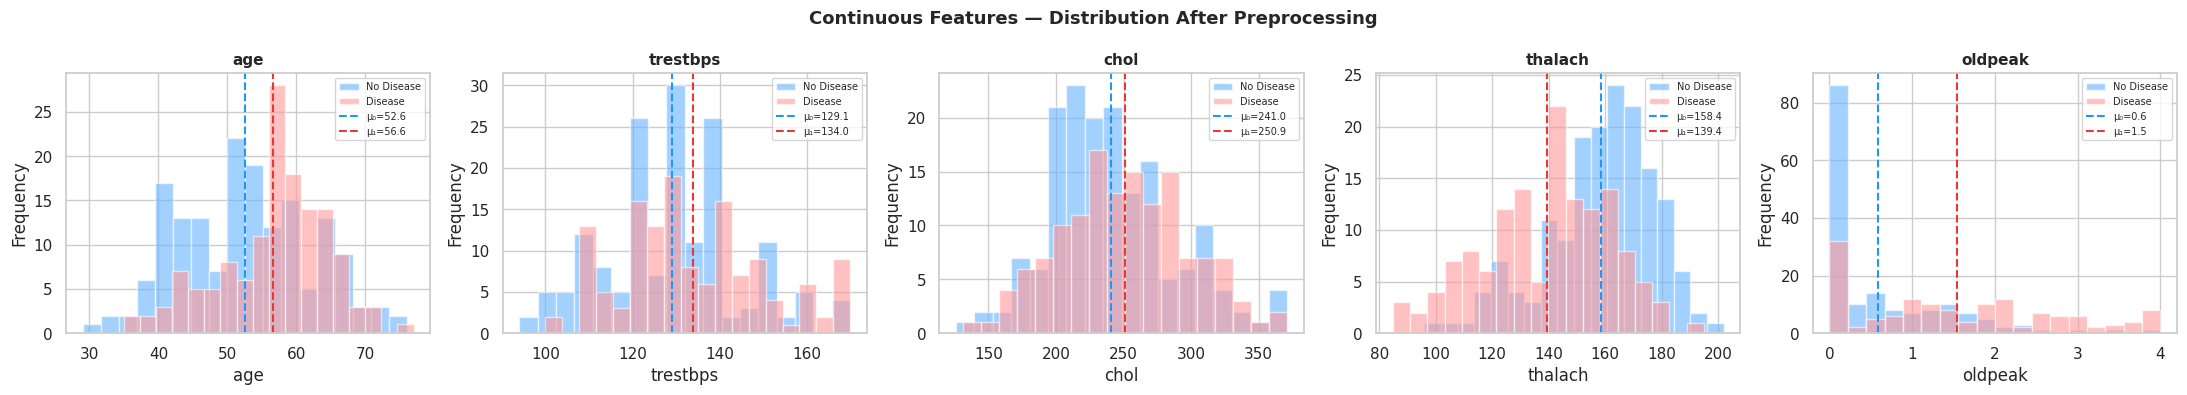

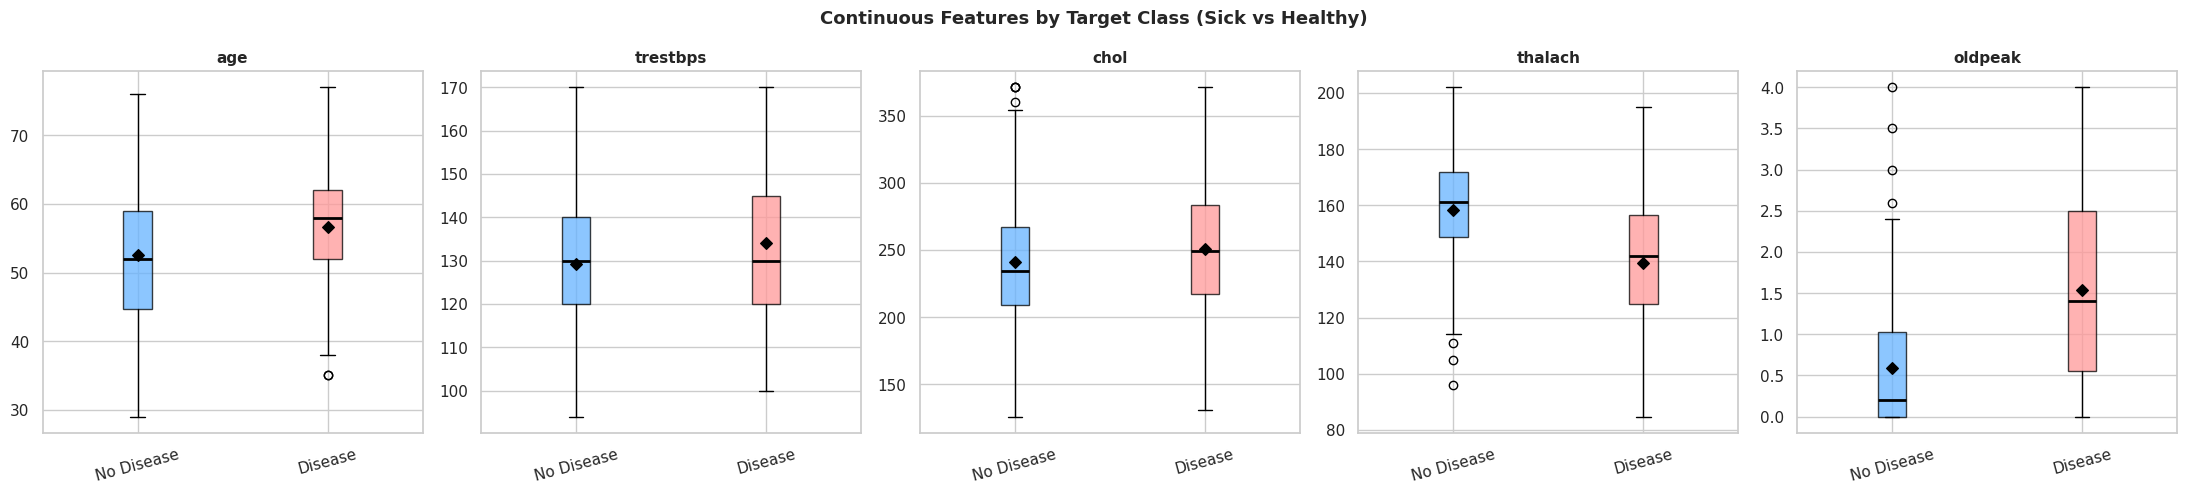

Mean Comparison (No Disease vs Disease):
  Feature      |   No Disease |    Disease |     Diff | Note
-----------------------------------------------------------------
  age          |        52.59 |      56.63 |    +4.04 | 📈 Higher in sick
  trestbps     |       129.13 |     133.96 |    +4.84 | 📈 Higher in sick
  chol         |       241.04 |     250.94 |    +9.90 | 📈 Higher in sick
  thalach      |       158.38 |     139.36 |   -19.02 | 📉 Lower in sick
  oldpeak      |         0.59 |       1.54 |    +0.96 | ≈ Similar


In [9]:
# ============================================================
# CELL 6 — Distribution Plots After Cleaning
# ============================================================

# ---- Plot A: Histograms of all continuous features ----
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(22, 4))
fig.suptitle('Continuous Features — Distribution After Preprocessing', fontsize=13, fontweight='bold')

for i, col in enumerate(continuous_cols):
    # Separate data by class
    data_0 = df_clean[df_clean[TARGET_COL] == 0][col]
    data_1 = df_clean[df_clean[TARGET_COL] == 1][col]

    # Overlay histograms: green = healthy, red = disease
    axes[i].hist(data_0, bins=18, color='#66b3ff', alpha=0.6, label='No Disease', edgecolor='white')
    axes[i].hist(data_1, bins=18, color='#ff9999', alpha=0.6, label='Disease',    edgecolor='white')

    # Vertical lines for the means of each class
    axes[i].axvline(data_0.mean(), color='#2196F3', linestyle='--', linewidth=1.5, label=f'μ₀={data_0.mean():.1f}')
    axes[i].axvline(data_1.mean(), color='#e53935', linestyle='--', linewidth=1.5, label=f'μ₁={data_1.mean():.1f}')

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('prep_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot B: Boxplots grouped by target (disease vs no disease) ----
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(22, 5))
fig.suptitle('Continuous Features by Target Class (Sick vs Healthy)', fontsize=13, fontweight='bold')

for i, col in enumerate(continuous_cols):
    # Group into two arrays: class 0 and class 1
    grp0 = df_clean[df_clean[TARGET_COL] == 0][col]
    grp1 = df_clean[df_clean[TARGET_COL] == 1][col]

    bp = axes[i].boxplot(
        [grp0, grp1],
        patch_artist=True,
        labels=['No Disease', 'Disease'],
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#66b3ff')   # Blue = No Disease
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor('#ff9999')   # Red = Disease
    bp['boxes'][1].set_alpha(0.75)

    # Diamond marker for the mean
    axes[i].scatter([1, 2], [grp0.mean(), grp1.mean()],
                    marker='D', color='black', s=35, zorder=5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('prep_class_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Print mean comparison table ----
print('Mean Comparison (No Disease vs Disease):')
print(f'  {"Feature":<12} | {"No Disease":>12} | {"Disease":>10} | {"Diff":>8} | Note')
print('-' * 65)
for col in continuous_cols:
    m0   = df_clean[df_clean[TARGET_COL] == 0][col].mean()
    m1   = df_clean[df_clean[TARGET_COL] == 1][col].mean()
    diff = m1 - m0
    note = '📈 Higher in sick' if diff > 2 else ('📉 Lower in sick' if diff < -2 else '≈ Similar')
    print(f'  {col:<12} | {m0:>12.2f} | {m1:>10.2f} | {diff:>+8.2f} | {note}')

---
## 🌡️ Cell 7 — Correlation Heatmap

> **Why here?** After cleaning, correlations are more accurate (no NaN distortion).  
> This tells us which features are most related to the target → a preview for Feature Selection.
Multicollinearity

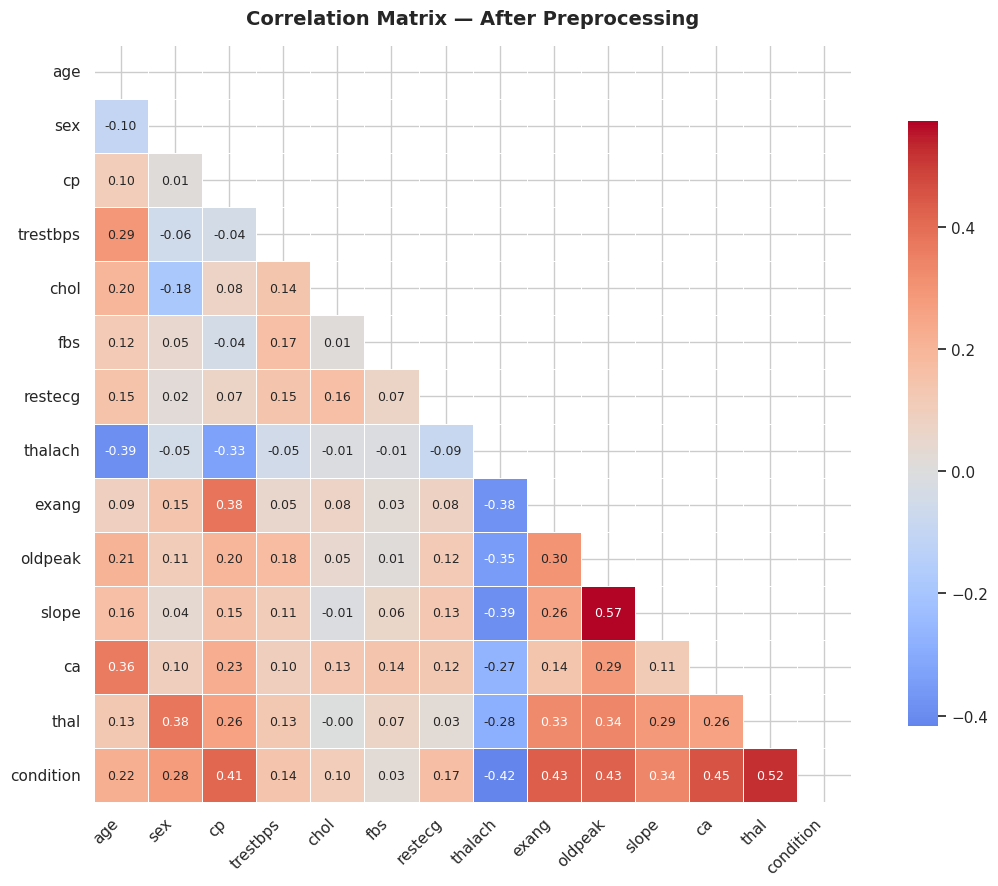

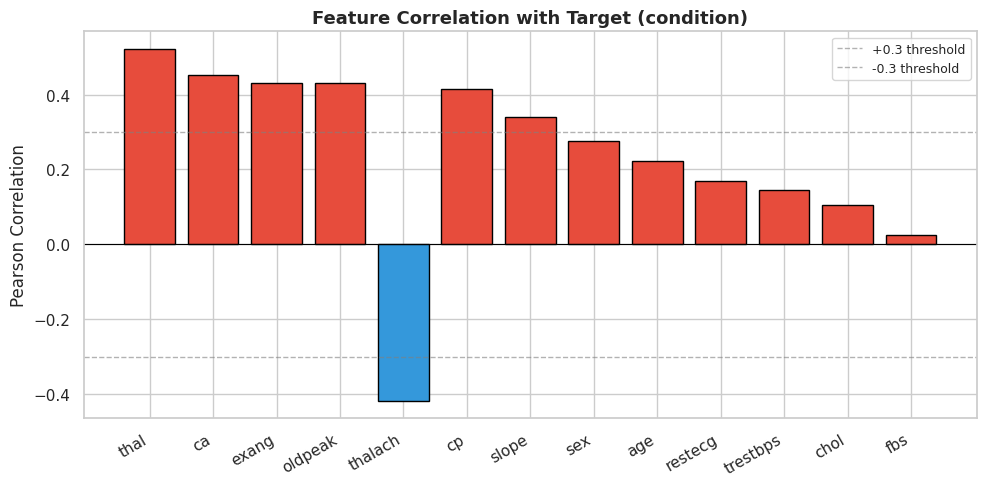

Top features correlated with target:
  ⭐ thal        : +0.522  (Positive ↑)
  ⭐ ca          : +0.454  (Positive ↑)
  ⭐ exang       : +0.432  (Positive ↑)
  ⭐ oldpeak     : +0.430  (Positive ↑)
  ⭐ thalach     : -0.418  (Negative ↓)
  ⭐ cp          : +0.414  (Positive ↑)
  ⭐ slope       : +0.339  (Positive ↑)
     sex         : +0.277  (Positive ↑)
     age         : +0.223  (Positive ↑)
     restecg     : +0.169  (Positive ↑)
     trestbps    : +0.145  (Positive ↑)
     chol        : +0.104  (Positive ↑)
     fbs         : +0.025  (Positive ↑)


In [10]:
# ============================================================
# CELL 7 — Correlation Heatmap (Post-Cleaning)
# ============================================================

corr_matrix = df_clean.corr()

# ---- Full correlation heatmap ----
plt.figure(figsize=(12, 9))

# mask=upper triangle → show only lower triangle to avoid redundancy
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='coolwarm',    # Red = positive, Blue = negative correlation
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — After Preprocessing', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('prep_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Feature correlation with target — ranked bar chart ----
# This gives us an early hint about which features matter most
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = plt.bar(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline( 0.3, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='+0.3 threshold')
plt.axhline(-0.3, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='-0.3 threshold')
plt.title('Feature Correlation with Target (condition)', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=30, ha='right')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('prep_target_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top features correlated with target:')
for feat, val in target_corr.items():
    direction = 'Positive ↑' if val > 0 else 'Negative ↓'
    flag      = '⭐' if abs(val) > 0.3 else '  '
    print(f'  {flag} {feat:<12}: {val:>+6.3f}  ({direction})')

---
## 🏷️ Cell 8 — One-Hot Encoding for Categorical Features

> **Why One-Hot Encoding?**  
> Columns like `cp` have values 0,1,2,3 — but 3 is NOT "more" than 0. They're just labels.  
> If we leave them as numbers, models (especially linear ones) will wrongly assume ordering.  
> One-Hot Encoding converts each category to its own 0/1 column.
>
> **Why `drop_first=True`?**  
> Avoids the *Dummy Variable Trap* — with k categories, k-1 dummies are enough.  
> The dropped category is implied when all other dummies are 0.

In [11]:
# ============================================================
# CELL 8 — One-Hot Encoding for Categorical Features
# ============================================================

print(f'Shape BEFORE encoding : {df_clean.shape}')
print(f'Columns to encode     : {categorical_cols}')
print()

# pd.get_dummies performs One-Hot Encoding
# columns=categorical_cols → only encode these specific columns
# drop_first=True          → drop first dummy to avoid multicollinearity
# dtype=int                → output 0/1 integers (not bool)
df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# Ensure binary columns are still clean integers
for col in binary_cols:
    df_encoded[col] = df_encoded[col].astype(int)

# Ensure target is still 0/1 integer
df_encoded[TARGET_COL] = df_encoded[TARGET_COL].astype(int)

print(f'Shape AFTER  encoding : {df_encoded.shape}')
print(f'New columns added     : {df_encoded.shape[1] - df_clean.shape[1]}')
print()
print('All columns after encoding:')
print('-' * 45)
for i, col in enumerate(df_encoded.columns, 1):
    tag = '  ← TARGET' if col == TARGET_COL else ''
    print(f'  {i:>2}. {col}{tag}')

# --- Example: show what happened to 'cp' ---
cp_cols = [c for c in df_encoded.columns if c.startswith('cp')]
print(f'\nExample — "cp" became: {cp_cols}')
print('  (original cp_0 was dropped → implied when all others are 0)')
print()
print('  ✅ One-Hot Encoding complete!')

Shape BEFORE encoding : (303, 14)
Columns to encode     : ['cp', 'restecg', 'slope', 'thal', 'ca']

Shape AFTER  encoding : (303, 23)
New columns added     : 9

All columns after encoding:
---------------------------------------------
   1. age
   2. sex
   3. trestbps
   4. chol
   5. fbs
   6. thalach
   7. exang
   8. oldpeak
   9. condition  ← TARGET
  10. cp_2.0
  11. cp_3.0
  12. cp_4.0
  13. restecg_1.0
  14. restecg_2.0
  15. slope_2.0
  16. slope_3.0
  17. thal_4
  18. thal_5
  19. thal_6
  20. thal_7
  21. ca_1
  22. ca_2
  23. ca_3

Example — "cp" became: ['cp_2.0', 'cp_3.0', 'cp_4.0']
  (original cp_0 was dropped → implied when all others are 0)

  ✅ One-Hot Encoding complete!


---
## ✂️ Cell 9 — Separate X / y + Train-Test Split

> **Why `stratify=y`?**  
> Without it, the random split might accidentally put most sick patients in train and few in test (or vice versa).  
> `stratify=y` guarantees the same class ratio (sick/healthy %) appears in BOTH train and test.

Features (X) : 303 samples × 22 features
Target   (y) : 303 samples
Features list: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']

Train-Test Split Results (80/20):
  Training set : 242 samples (79.9%)
  Test set     : 61 samples (20.1%)

  Train class distribution: 0=131 (54.1%)  |  1=111 (45.9%)
  Test  class distribution: 0=33 (54.1%)   |  1=28 (45.9%)


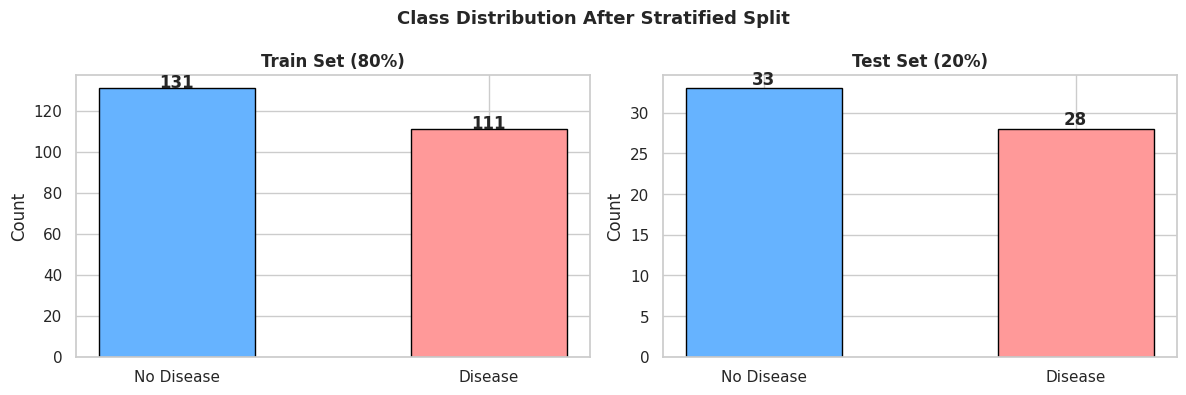

  ✅ Stratified Train-Test split done!


In [12]:
# ============================================================
# CELL 9 — Separate X/y + Stratified Train-Test Split
# ============================================================

# --- Separate features from target ---
X = df_encoded.drop(TARGET_COL, axis=1)   # Everything except the target
y = df_encoded[TARGET_COL]                # Only the target column

print(f'Features (X) : {X.shape[0]} samples × {X.shape[1]} features')
print(f'Target   (y) : {y.shape[0]} samples')
print(f'Features list: {list(X.columns)}')

# --- Train / Test split ---
# test_size=0.2    → 20% for testing, 80% for training
# random_state=42  → fixed seed → same split every time we run (reproducibility)
# stratify=y       → maintain the class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Reset indices to avoid alignment issues later
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'\nTrain-Test Split Results (80/20):')
print(f'  Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

tr0 = (y_train == 0).sum(); tr1 = (y_train == 1).sum()
te0 = (y_test  == 0).sum(); te1 = (y_test  == 1).sum()
print(f'\n  Train class distribution: 0={tr0} ({tr0/len(y_train)*100:.1f}%)  |  1={tr1} ({tr1/len(y_train)*100:.1f}%)')
print(f'  Test  class distribution: 0={te0} ({te0/len(y_test)*100:.1f}%)   |  1={te1} ({te1/len(y_test)*100:.1f}%)')

# --- Visualize the split ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#66b3ff', '#ff9999']

for ax, (name, yd) in zip(axes, [('Train Set (80%)', y_train), ('Test Set (20%)', y_test)]):
    cnts = yd.value_counts().sort_index()
    bars = ax.bar(['No Disease', 'Disease'], cnts.values, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5, str(val), ha='center', fontweight='bold', fontsize=12)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution After Stratified Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prep_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('  ✅ Stratified Train-Test split done!')

---
## ⚖️ Cell 10 — SMOTE (Synthetic Minority Over-sampling Technique)(Applied to Train Set Only!)

> **Why SMOTE?**  
> If one class has more samples, the model learns to always predict the majority class.  
> SMOTE generates *synthetic* minority samples by interpolating between real ones (using KNN).
>
> **Why train only?**  
> The test set must reflect the *real-world* distribution — never touch it.  
> Applying SMOTE to test would give us artificially inflated performance numbers.

Class distribution BEFORE SMOTE (train set):
  {0: 131, 1: 111}
  Balance ratio: 0.85

  ⚠️  Imbalance detected → Applying SMOTE...
  BEFORE SMOTE: 242 samples  →  {0: 131, 1: 111}
  AFTER  SMOTE: 262 samples  →  {1: 131, 0: 131}
  Synthetic samples added: 20


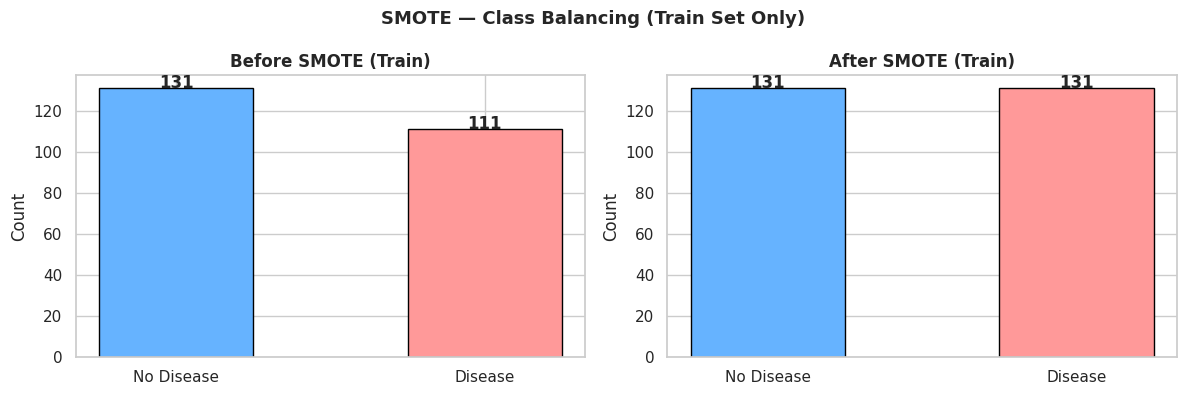

  ✅ SMOTE step complete!


In [13]:
# ============================================================
# CELL 10 — SMOTE — Synthetic Minority Over-sampling (Train Only)
# ============================================================

print('Class distribution BEFORE SMOTE (train set):')
print(f'  {y_train.value_counts().to_dict()}')

balance_ratio = y_train.value_counts().min() / y_train.value_counts().max()
print(f'  Balance ratio: {balance_ratio:.2f}')
print()

# Decide whether to apply SMOTE based on the imbalance ratio
# If ratio < 0.85, the classes are considered meaningfully imbalanced
if balance_ratio < 0.85:
    print('  ⚠️  Imbalance detected → Applying SMOTE...')

    # SMOTE works by:
    # 1. Finding minority class samples
    # 2. For each sample, picking k nearest neighbors (also minority)
    # 3. Creating new synthetic points on the line between them
    # random_state=42 → reproducibility
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Convert back to Series to preserve column names
    X_train_sm = pd.DataFrame(X_train_sm, columns=X.columns)
    y_train_sm = pd.Series(y_train_sm, name=TARGET_COL)

    print(f'  BEFORE SMOTE: {X_train.shape[0]} samples  →  {y_train.value_counts().to_dict()}')
    print(f'  AFTER  SMOTE: {X_train_sm.shape[0]} samples  →  {y_train_sm.value_counts().to_dict()}')
    print(f'  Synthetic samples added: {X_train_sm.shape[0] - X_train.shape[0]}')
    SMOTE_APPLIED = True

else:
    # Already balanced — no need for SMOTE
    X_train_sm = X_train.copy()
    y_train_sm = y_train.copy()
    print('  ✅ Classes are already balanced. SMOTE not needed.')
    SMOTE_APPLIED = False

# --- Visualize before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#66b3ff', '#ff9999']

for ax, (title, yd) in zip(axes, [
    ('Before SMOTE (Train)', y_train),
    ('After SMOTE (Train)',  y_train_sm)
]):
    cnts = pd.Series(yd).value_counts().sort_index()
    bars = ax.bar(['No Disease', 'Disease'], cnts.values, color=colors, edgecolor='black', width=0.5)
    for bar, val in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5, str(val), ha='center', fontweight='bold', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('SMOTE — Class Balancing (Train Set Only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prep_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print('  ✅ SMOTE step complete!')

---
## 📏 Cell 11 — Feature Scaling (StandardScaler)

> **Why scale?**  
> `age` ranges 29–77 but `chol` ranges 126–564. Models like SVM and Logistic Regression treat larger numbers as more important — which is wrong.  
> StandardScaler makes every feature have **mean=0** and **std=1** — they all speak the same scale.
>
> **⚠️ Critical: `fit()` on train only!**  
> If we include test data in `fit()`, the scaler learns the test distribution → **Data Leakage**.  
> This inflates performance numbers and the model would fail in the real world.

Scaling Verification (continuous features should be ≈ mean=0, std=1):
-------------------------------------------------------
  ✅ age          | mean:  0.0000 | std: 1.0019
  ✅ trestbps     | mean:  0.0000 | std: 1.0019
  ✅ chol         | mean: -0.0000 | std: 1.0019
  ✅ thalach      | mean: -0.0000 | std: 1.0019
  ✅ oldpeak      | mean:  0.0000 | std: 1.0019

  X_train_scaled shape : (262, 22)
  X_test_scaled  shape : (61, 22)


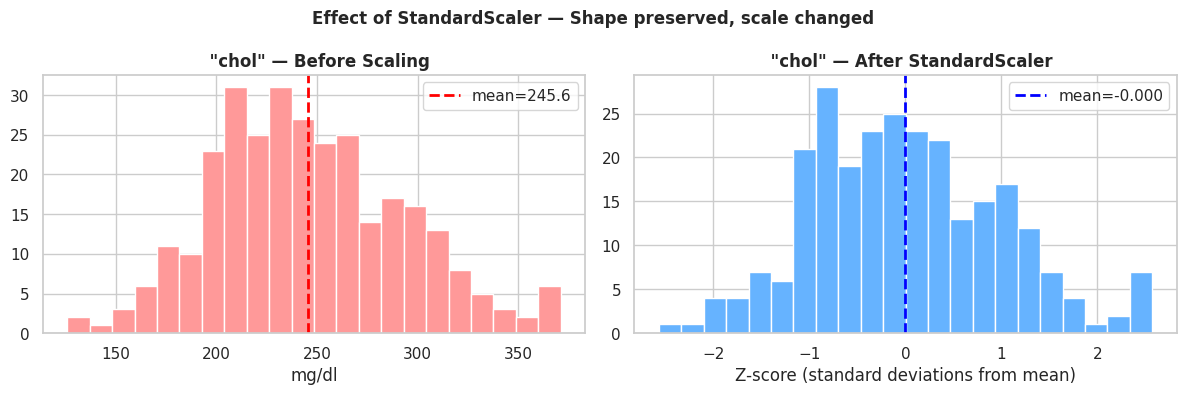

  ✅ Feature scaling done!


In [14]:
# ============================================================
# CELL 11 — Feature Scaling (StandardScaler)
# ============================================================

# StandardScaler formula: z = (x - mean) / std
# Result: mean ≈ 0, std ≈ 1 for every feature
scaler = StandardScaler()

# --- fit_transform on TRAIN: learn mean/std from train, then transform ---
X_train_arr = scaler.fit_transform(X_train_sm)

# --- transform only on TEST: apply train's mean/std to test (no learning) ---
X_test_arr  = scaler.transform(X_test)

# Convert numpy arrays back to DataFrames with proper column names
# This makes it much easier to work with in Feature Selection notebook
X_train_scaled = pd.DataFrame(X_train_arr, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_arr,  columns=X.columns)

# --- Verify scaling worked correctly ---
print('Scaling Verification (continuous features should be ≈ mean=0, std=1):')
print('-' * 55)
for col in continuous_cols:
    m = X_train_scaled[col].mean()
    s = X_train_scaled[col].std()
    ok = '✅' if (abs(m) < 0.05 and abs(s - 1) < 0.05) else '⚠️'
    print(f'  {ok} {col:<12} | mean: {m:>7.4f} | std: {s:.4f}')

print(f'\n  X_train_scaled shape : {X_train_scaled.shape}')
print(f'  X_test_scaled  shape : {X_test_scaled.shape}')

# --- Visualize: one feature before vs after scaling ---
ref_col = 'chol'   # cholesterol — good example: large original range

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling (original cleaned data)
axes[0].hist(df_clean[ref_col], bins=22, color='#ff9999', edgecolor='white')
axes[0].axvline(df_clean[ref_col].mean(), color='red', linestyle='--', linewidth=2,
                label=f'mean={df_clean[ref_col].mean():.1f}')
axes[0].set_title(f'  "{ref_col}" — Before Scaling', fontsize=12, fontweight='bold')
axes[0].set_xlabel('mg/dl')
axes[0].legend()

# After scaling (z-scores)
axes[1].hist(X_train_scaled[ref_col], bins=22, color='#66b3ff', edgecolor='white')
axes[1].axvline(X_train_scaled[ref_col].mean(), color='blue', linestyle='--', linewidth=2,
                label=f'mean={X_train_scaled[ref_col].mean():.3f}')
axes[1].set_title(f'  "{ref_col}" — After StandardScaler', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Z-score (standard deviations from mean)')
axes[1].legend()

plt.suptitle('Effect of StandardScaler — Shape preserved, scale changed',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('prep_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print('  ✅ Feature scaling done!')

---
## ✅ Cell 12 — Full Validation Checks

> **Why validate before saving?**  
> Catching a mistake here is much easier than debugging it in the next notebook.  
> We check: no missing values, correct shapes, proper scaling, matching column names.

In [15]:
# ============================================================
# CELL 12 — Final Validation Checks Before Saving
# ============================================================

print('RUNNING VALIDATION CHECKS...')
print('=' * 55)
errors = []   # Collect any issues found

# --- Check 1: No missing values in any split ---
for name, data in [
    ('X_train_scaled', X_train_scaled),
    ('X_test_scaled',  X_test_scaled)
]:
    n = data.isnull().sum().sum()
    if n == 0:
        print(f'  ✅ No missing values in {name}')
    else:
        msg = f'{name} has {n} missing values!'
        print(f'  ❌ {msg}')
        errors.append(msg)

# --- Check 2: Same number of features in train and test ---
if X_train_scaled.shape[1] == X_test_scaled.shape[1]:
    print(f'  ✅ Feature count matches: {X_train_scaled.shape[1]} features in both')
else:
    msg = f'Feature mismatch! Train={X_train_scaled.shape[1]}, Test={X_test_scaled.shape[1]}'
    print(f'  ❌ {msg}')
    errors.append(msg)

# --- Check 3: StandardScaler applied correctly ---
mean_vals = X_train_scaled[continuous_cols].mean()
std_vals  = X_train_scaled[continuous_cols].std()
mean_ok   = (mean_vals.abs() < 0.05).all()
std_ok    = ((std_vals - 1).abs() < 0.05).all()
if mean_ok and std_ok:
    print('  ✅ StandardScaler correct (mean≈0, std≈1 for continuous cols)')
else:
    msg = 'Scaling verification failed!'
    print(f'  ⚠️  {msg}')
    errors.append(msg)

# --- Check 4: Column names are identical between train and test ---
if list(X_train_scaled.columns) == list(X_test_scaled.columns):
    print('  ✅ Column names match between train and test')
else:
    msg = 'Column name mismatch between train and test!'
    print(f'  ❌ {msg}')
    errors.append(msg)

# --- Check 5: Target values are only 0 and 1 ---
y_vals = set(y_train_sm.unique()) | set(y_test.unique())
if y_vals == {0, 1}:
    print('  ✅ Target values are binary (0 and 1 only)')
else:
    msg = f'Target has unexpected values: {y_vals}'
    print(f'  ❌ {msg}')
    errors.append(msg)

# --- Check 6: SMOTE worked (if applied) ---
if SMOTE_APPLIED:
    r = y_train_sm.value_counts().min() / y_train_sm.value_counts().max()
    if r > 0.95:
        print(f'  ✅ SMOTE balanced classes correctly (ratio={r:.2f})')
    else:
        print(f'  ⚠️  SMOTE result ratio={r:.2f} (less than ideal)')
else:
    print('  ✅ Classes were balanced — SMOTE correctly skipped')

# --- Final verdict ---
print('=' * 55)
if not errors:
    print('  ✅ ALL CHECKS PASSED — Safe to save!')
else:
    print(f'  ❌ {len(errors)} issue(s) found — fix before saving:')
    for e in errors:
        print(f'     → {e}')

RUNNING VALIDATION CHECKS...
  ✅ No missing values in X_train_scaled
  ✅ No missing values in X_test_scaled
  ✅ Feature count matches: 22 features in both
  ✅ StandardScaler correct (mean≈0, std≈1 for continuous cols)
  ✅ Column names match between train and test
  ✅ Target values are binary (0 and 1 only)
  ✅ SMOTE balanced classes correctly (ratio=1.00)
  ✅ ALL CHECKS PASSED — Safe to save!


---
## 💾 Cell 13 — Save All Outputs

> **What we save and why:**  
> - **Scaled data** → for models that need scaling (SVM, Logistic Regression, KNN)  
> - **Raw (unscaled) data** → for tree-based models (Decision Tree, Random Forest, XGBoost) that don't need scaling  
> - **Scaler object** → to transform any new unseen data consistently  
> - **Feature names** → critical for Feature Selection to know which column is which

In [16]:
# ============================================================
# CELL 13 — Save All Outputs for Feature Selection Notebook
# ============================================================

# Mount Google Drive to save files persistently
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# # Create the project output folder
# SAVE_DIR = '/content/drive/MyDrive/heart_project/saved_data'
SAVE_DIR = r'C:\Users\Ruhe\Desktop\heart+disease\saved_data'

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Saving all outputs to: {SAVE_DIR}')
print()

# ---- 1. Training features — SCALED (after SMOTE) ----
# For: SVM, Logistic Regression, KNN, Neural Networks
joblib.dump(X_train_scaled,  f'{SAVE_DIR}/X_train_scaled.pkl')
print('  ✅ X_train_scaled.pkl     → scaled train features (post-SMOTE)')

# ---- 2. Test features — SCALED ----
# For: final model evaluation (never used in training)
joblib.dump(X_test_scaled,   f'{SAVE_DIR}/X_test_scaled.pkl')
print('  ✅ X_test_scaled.pkl      → scaled test features')

# ---- 3. Training labels (after SMOTE) ----
joblib.dump(y_train_sm,      f'{SAVE_DIR}/y_train.pkl')
print('  ✅ y_train.pkl            → train labels (after SMOTE)')

# ---- 4. Test labels (original — never modified) ----
joblib.dump(y_test,          f'{SAVE_DIR}/y_test.pkl')
print('  ✅ y_test.pkl             → test labels (original, untouched)')

# ---- 5. StandardScaler object ----
# Needed to transform any new data the same way
joblib.dump(scaler,          f'{SAVE_DIR}/scaler.pkl')
print('  ✅ scaler.pkl             → fitted StandardScaler object')

# ---- 6. Training features — RAW / UNSCALED (after SMOTE) ----
# For: Decision Tree, Random Forest, XGBoost (don't need scaling)
joblib.dump(X_train_sm,      f'{SAVE_DIR}/X_train_raw.pkl')
print('  ✅ X_train_raw.pkl        → unscaled train features (post-SMOTE)')

# ---- 7. Test features — RAW / UNSCALED ----
joblib.dump(X_test,          f'{SAVE_DIR}/X_test_raw.pkl')
print('  ✅ X_test_raw.pkl         → unscaled test features')

# ---- 8. Feature names list ----
# Critical for Feature Selection — maps column index to feature name
feature_names = list(X.columns)
joblib.dump(feature_names,   f'{SAVE_DIR}/feature_names.pkl')
print('  ✅ feature_names.pkl      → list of feature names after encoding')

# ---- 9. Target column name ----
joblib.dump(TARGET_COL,      f'{SAVE_DIR}/target_col_name.pkl')
print('  ✅ target_col_name.pkl    → target column name string')

# ---- 10. Cleaned (encoded, unscaled) full dataset ----
# Useful for quick reference in Feature Selection
df_encoded.to_csv(f'{SAVE_DIR}/heart_preprocessed.csv', index=False)
print('  ✅ heart_preprocessed.csv → full encoded & cleaned dataset')

print()
print('  ✅ All 10 files saved successfully!')

Saving all outputs to: C:\Users\Ruhe\Desktop\heart+disease\saved_data

  ✅ X_train_scaled.pkl     → scaled train features (post-SMOTE)
  ✅ X_test_scaled.pkl      → scaled test features
  ✅ y_train.pkl            → train labels (after SMOTE)
  ✅ y_test.pkl             → test labels (original, untouched)
  ✅ scaler.pkl             → fitted StandardScaler object
  ✅ X_train_raw.pkl        → unscaled train features (post-SMOTE)
  ✅ X_test_raw.pkl         → unscaled test features
  ✅ feature_names.pkl      → list of feature names after encoding
  ✅ target_col_name.pkl    → target column name string
  ✅ heart_preprocessed.csv → full encoded & cleaned dataset

  ✅ All 10 files saved successfully!


---
## 📋 Cell 14 — Final Summary Report

In [17]:
# ============================================================
# CELL 14 — Final Preprocessing Summary Report
# ============================================================

print('=' * 65)
print('         PREPROCESSING SUMMARY REPORT')
print('    Heart Disease Prediction — UCI Cleveland Dataset')
print('=' * 65)

print(f'\n  INPUT (from EDA notebook):')
print(f'    File              : processed.cleveland.data')
print(f'    Shape             : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'    Target column     : "{TARGET_COL}"  (binary: 0=healthy, 1=disease)')
print(f'    Missing values    : {df.isnull().sum().sum()} total (in ca, thal)')

print(f'\n  STEP 1 — Missing Values (KNN Imputer):')
print(f'    Method     : KNNImputer(n_neighbors=5)')
print(f'    Affected   : ca, thal — {df.isnull().sum().sum()} total NaNs filled')
print(f'    Why KNN    : Considers feature relationships (smarter than mean/median)')

print(f'\n  STEP 2 — Outlier Treatment (IQR Capping):')
print(f'    Method     : Winsorization — clip to [Q1-1.5×IQR, Q3+1.5×IQR]')
print(f'    Applied to : {continuous_cols}')
print(f'    Total capped: {total_capped} values')
print(f'    Why Capping: Preserves all {df.shape[0]} samples — no data loss')

print(f'\n  STEP 3 — One-Hot Encoding:')
print(f'    Applied to : {categorical_cols}')
print(f'    drop_first : True (avoids Dummy Variable Trap)')
print(f'    Columns    : {df.shape[1]-1} → {df_encoded.shape[1]-1} features')

print(f'\n  STEP 4 — Train-Test Split:')
print(f'    Ratio      : 80% train / 20% test')
print(f'    Train      : {X_train.shape[0]} samples')
print(f'    Test       : {X_test.shape[0]} samples')
print(f'    stratify=y : Yes — class ratio preserved in both sets')
print(f'    random_state: 42 (reproducible)')

smote_desc = f'Yes — {X_train.shape[0]} → {X_train_sm.shape[0]} samples' if SMOTE_APPLIED else 'No — classes already balanced'
print(f'\n  STEP 5 — SMOTE (Train Only):')
print(f'    Applied    : {smote_desc}')
print(f'    Why train  : Test set must reflect real-world distribution')

print(f'\n  STEP 6 — Feature Scaling (StandardScaler):')
print(f'    Formula    : z = (x - mean) / std')
print(f'    fit() on   : TRAIN only → prevents data leakage')
print(f'    Result     : mean≈0, std≈1 for all continuous features')

print(f'\n  OUTPUT FILES (saved to Drive):')
print(f'    X_train_scaled.pkl  : {X_train_scaled.shape}  → for SVM, LR, KNN')
print(f'    X_test_scaled.pkl   : {X_test_scaled.shape}   → for evaluation')
print(f'    X_train_raw.pkl     : {X_train_sm.shape}  → for DT, RF, XGBoost')
print(f'    X_test_raw.pkl      : {X_test.shape}   → for evaluation (unscaled)')
print(f'    y_train.pkl / y_test.pkl / scaler.pkl / feature_names.pkl')

print()
print('=' * 65)
print('  ✅ Phase 3 Complete!')
print('=' * 65)

         PREPROCESSING SUMMARY REPORT
    Heart Disease Prediction — UCI Cleveland Dataset

  INPUT (from EDA notebook):
    File              : processed.cleveland.data
    Shape             : 303 rows × 14 columns
    Target column     : "condition"  (binary: 0=healthy, 1=disease)
    Missing values    : 6 total (in ca, thal)

  STEP 1 — Missing Values (KNN Imputer):
    Method     : KNNImputer(n_neighbors=5)
    Affected   : ca, thal — 6 total NaNs filled
    Why KNN    : Considers feature relationships (smarter than mean/median)

  STEP 2 — Outlier Treatment (IQR Capping):
    Method     : Winsorization — clip to [Q1-1.5×IQR, Q3+1.5×IQR]
    Applied to : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    Total capped: 20 values
    Why Capping: Preserves all 303 samples — no data loss

  STEP 3 — One-Hot Encoding:
    Applied to : ['cp', 'restecg', 'slope', 'thal', 'ca']
    drop_first : True (avoids Dummy Variable Trap)
    Columns    : 13 → 22 features

  STEP 4 — Train-Test S